# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter,filtfilt
# from sklearn.preprocessing import MinMaxScaler
import pickle
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import keras
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

# Functions

In [2]:

def calculate_metrics(y_true, y_pred, model_name):
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100  # em porcentagem
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # print(f"\nMétricas para {model_name.upper()}:")
    # print(f"MAPE: {mape:.2f}%")
    # print(f"MAE: {mae:.4f}")
    # print(f"R²: {r2:.4f}")
    
    return mape, mae, r2


def rungeKutta(x0, h, dvFunc, *args):
    # 1a chamada
    xd=dvFunc(x0, *args)
    savex0 = x0
    phi = xd
    x0 = savex0 + 0.5*h*xd

    # 2a chamada
    xd = dvFunc(x0, *args)
    phi = phi + 2*xd
    x0 = savex0 + 0.5*h*xd

    # 3a chamada
    xd = dvFunc(x0, *args)
    phi = phi+2*xd
    x0 = savex0+h*xd

    # 4a chamada
    xd = dvFunc(x0, *args)
    k = (phi+xd)/6
    x = savex0 + k*h
    return x


def butter_lowpass_filter(data, cutoff=1, fs=1000, order=5):
    nyq = 0.5 * fs  # Nyquist Frequency
    normal_cutoff = cutoff / nyq
    # Get the filter coefficients 
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y


def dvFunc(_h, _udot, A = 0.9, beta = 0.008, gamma = 0.008):
    return A*_udot - beta*abs(_udot)*_h - gamma*_udot*abs(_h)


def simulate(u, udot, dp = 1.6):
    ht = np.zeros((len(u)))
    y = np.zeros((len(u)))
    h = 0.001
    for k in range(1,len(u)):
        ht[k]=rungeKutta(ht[k-1],h,dvFunc,udot[k-1])
        y[k] = dp*u[k] - ht[k]
    return y


def save(filename, dictionary):
    with open(filename, 'wb') as f:
        pickle.dump(dictionary,f)
        f.close()


def create_sequences(u_data, y_data, time_steps=30):
    X, y = [], []

    for i in range(len(u_data) - time_steps):
        seq = np.column_stack((u_data[i:(i + time_steps)], 
                              y_data[i:(i + time_steps)]))
        X.append(seq)
        y.append(y_data[i + time_steps])

    return np.array(X), np.array(y)

@keras.saving.register_keras_serializable()
def r_squared(y_true, y_pred):
    SS_res = K.sum(K.square(y_true - y_pred)) 
    SS_tot = K.sum(K.square(y_true - K.mean(y_true))) 
    # return K.clip(1 - SS_res/(SS_tot + K.epsilon()), 0, 1) 
    return 1 - SS_res/SS_tot 

# Theoretical System Bouc-Wen Model

In [3]:
# Filter requirements.
fs = 1000       # sample rate, Hz
cutoff = 1     # desired cutoff frequency of the filter, Hz ,      slightly higher than actual 1.2 Hz
nyq = 0.5 * fs  # Nyquist Frequency
order = 5      # sin wave can be approx represented as quadratic

In [22]:
t = np.arange(0,101,1/fs)
seed = 93862723
np.random.seed(seed)
dataX = np.random.normal(0, 450, size=(len(t)))
dataX[0:1000] = 0
dataX[-1000:] = 0
u = butter_lowpass_filter(dataX, cutoff, fs, order)
u = u.reshape(-1)
udot = np.diff(u)/np.diff(t)
udot = udot[999:]
u = u[1000:]
t = t[1000:]

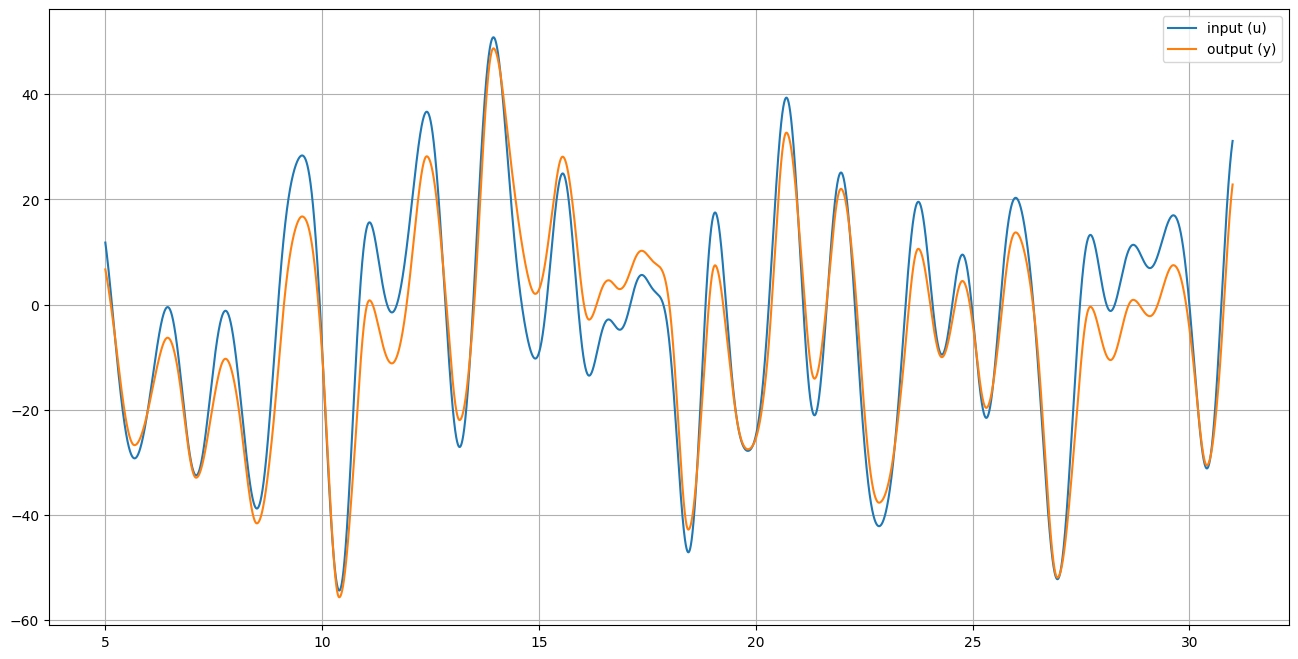

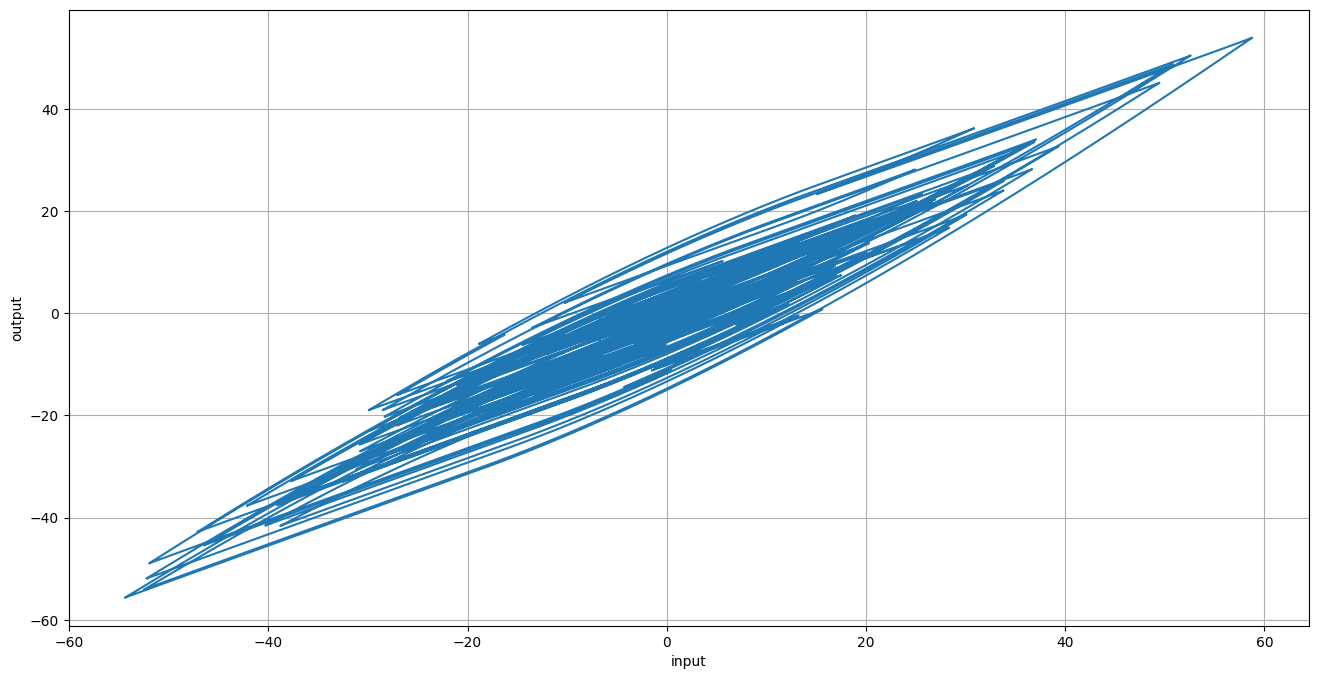

In [30]:
# ----------------------------------------------------------
# ----------------------- TRAIN DATA -----------------------
# ----------------------------------------------------------

y = simulate(u, udot)
plt.figure(figsize=(16, 8))
plt.plot(t[4000:30000], u[4000:30000], label="input (u)")
plt.plot(t[4000:30000], y[4000:30000], label="output (y)")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(16, 8))
plt.plot(u, y, label="input (u)")
plt.xlabel("input")
plt.ylabel("output")
plt.grid()
plt.show()

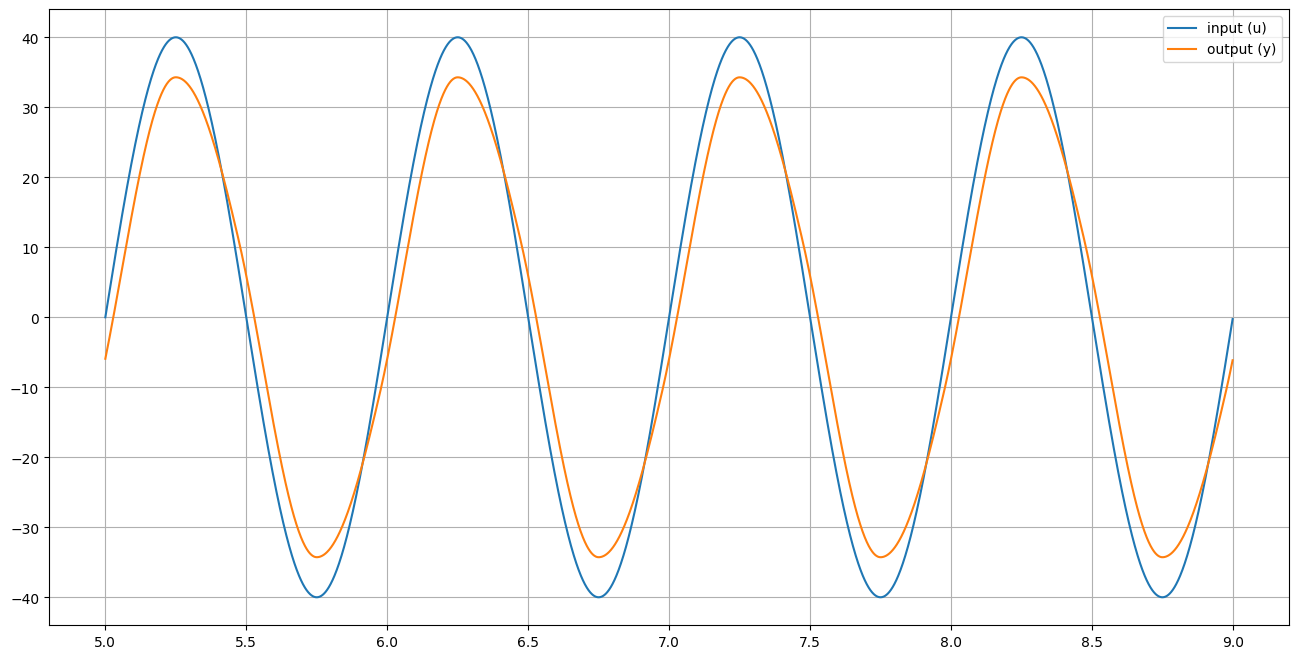

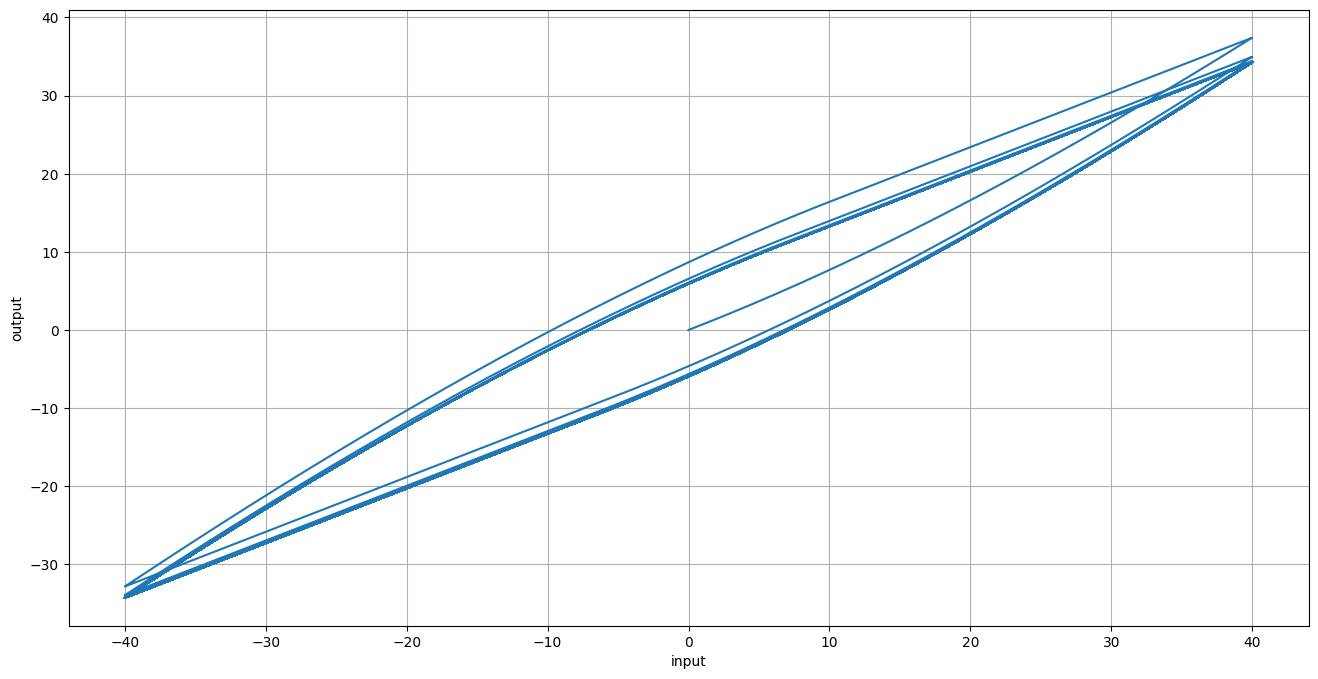

In [20]:
# ----------------------------------------------------------
# ----------------------- TEST DATA -----------------------
# ----------------------------------------------------------

u = 40*np.sin(2*np.pi*t)
udot = np.diff(u)/np.diff(t)
y = simulate(u, udot)

plt.figure(figsize=(16, 8))
plt.plot(t[4000:8000], u[4000:8000], label="input (u)")
plt.plot(t[4000:8000], y[4000:8000], label="output (y)")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(16, 8))
plt.plot(u, y, label="input (u)")
plt.xlabel("input")
plt.ylabel("output")
plt.grid()
plt.show()

# Execute Predict Train

In [23]:
fs = 1000       # sample rate, Hz
cutoff = 1     # desired cutoff frequency of the filter, Hz ,      slightly higher than actual 1.2 Hz
nyq = 0.5 * fs  # Nyquist Frequency
order = 5      # sin wave can be approx represented as quadratic

t = np.arange(0, 101, 1/fs)
seed = 93862723
seed = 32
np.random.seed(seed)
dataX = np.random.normal(0, 450, size=(len(t)))
dataX[0:1000] = 0
dataX[-1000:] = 0
u = butter_lowpass_filter(dataX, cutoff, fs, order)
u = u.reshape(-1)
udot = np.diff(u)/np.diff(t)
udot = udot[999:]
u = u[1000:]
t = t[1000:]
y = simulate(u, udot)

scaler = MinMaxScaler(feature_range=(-1, 1))
u_scaled = scaler.fit_transform(u.reshape(-1, 1)).flatten()

X, y_test = create_sequences(u_data=u_scaled, y_data=y)

best_models = {
    'lstm': load_model(f'checkpoints_stock_mssp/lstm_best.keras'),
    'gru': load_model(f'checkpoints_stock_mssp/gru_best.keras'),
    'mlp': load_model(f'checkpoints_stock_mssp/mlp_best.keras')
}

lstm_pred = best_models['lstm'].predict(X)
gru_pred = best_models['gru'].predict(X)
mlp_pred = best_models['mlp'].predict(X)

lstm_metrics = calculate_metrics(y_test, lstm_pred, 'lstm')
gru_metrics = calculate_metrics(y_test, gru_pred, 'gru')
mlp_metrics = calculate_metrics(y_test, mlp_pred, 'mlp')


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3s 951us/step


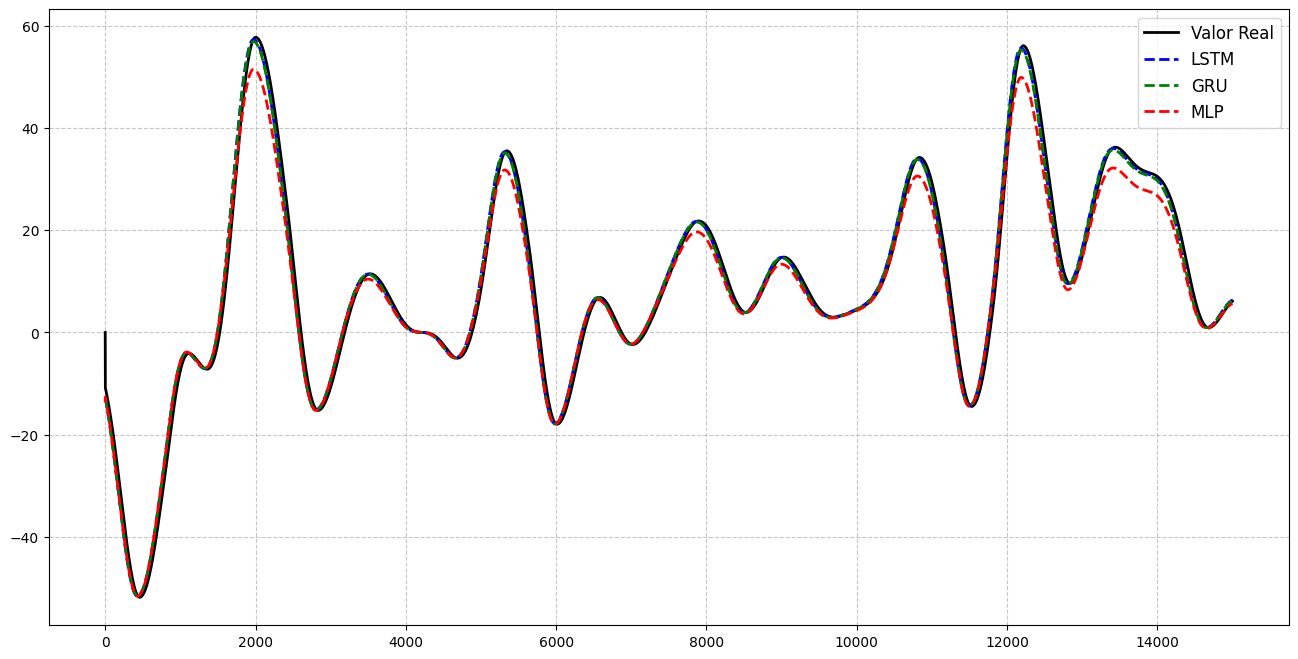

In [24]:
samples = 15000
plt.figure(figsize=(16, 8))
plt.plot(y[:samples], label=f'Valor Real', linewidth=2, color='k')
plt.plot(lstm_pred[:samples], '--', label='LSTM', linewidth=2, color='b')
plt.plot(gru_pred[:samples], '--', label='GRU', linewidth=2, color='g')
plt.plot(mlp_pred[:samples], '--', label='MLP', linewidth=2, color='r')
# plt.ylabel(" ")
# plt.xlabel(' ')
# plt.title(f' ', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
# plt.xticks(rotation=45)
# plt.savefig(f'final-results.png', dpi=300, bbox_inches='tight') 
plt.show()

In [25]:
metrics_df = pd.DataFrame({
    'Modelo': ['LSTM', 'GRU', 'MLP'],
    'MAPE (%)': [lstm_metrics[0], gru_metrics[0], mlp_metrics[0]],
    'MAE': [lstm_metrics[1], gru_metrics[1], mlp_metrics[1]],
    'R²': [lstm_metrics[2], gru_metrics[2], mlp_metrics[2]]
})

print("\nResumo das Métricas:")
print(metrics_df.to_string(index=False))


Resumo das Métricas:
Modelo  MAPE (%)      MAE       R²
  LSTM  2.614318 0.090295 0.999959
   GRU  2.254926 0.137011 0.999869
   MLP 10.506390 0.932170 0.992023


# Execute Predict Validation

In [18]:
fs = 1000
t = np.arange(0, 101, 1/fs)
scaler = MinMaxScaler(feature_range=(-1, 1))

u = 40*np.sin(2*np.pi*t)
u_scaled = scaler.fit_transform(u.reshape(-1, 1)).flatten()
udot = np.diff(u)/np.diff(t)
y = simulate(u, udot)
X, y_test = create_sequences(u_data=u_scaled, y_data=y)

best_models = {
    'lstm': load_model(f'checkpoints_stock_mssp/lstm_best.keras'),
    'gru': load_model(f'checkpoints_stock_mssp/gru_best.keras'),
    'mlp': load_model(f'checkpoints_stock_mssp/mlp_best.keras')
}

lstm_pred = best_models['lstm'].predict(X)
gru_pred = best_models['gru'].predict(X)
mlp_pred = best_models['mlp'].predict(X)

lstm_metrics = calculate_metrics(y_test, lstm_pred, 'lstm')
gru_metrics = calculate_metrics(y_test, gru_pred, 'gru')
mlp_metrics = calculate_metrics(y_test, mlp_pred, 'mlp')

# print(f"RMSE LSTM: {round(mean_squared_error(lstm_pred[initial_data:, i], y[initial_data:, i]), 4)}\n")
# print(f"RMSE GRU: {round(mean_squared_error(gru_pred[initial_data:, i], y[initial_data:, i]), 4)}\n")
# print(f"RMSE MLP: {round(mean_squared_error(mlp_pred[initial_data:, i], y[initial_data:, i]), 4)}\n")

3156/3156 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 3s 933us/step

Métricas para LSTM:
MAPE: 0.72%
MAE: 0.0860
R²: 1.0000

Métricas para GRU:
MAPE: 0.93%
MAE: 0.0929
R²: 1.0000

Métricas para MLP:
MAPE: 5.20%
MAE: 0.9150
R²: 0.9968


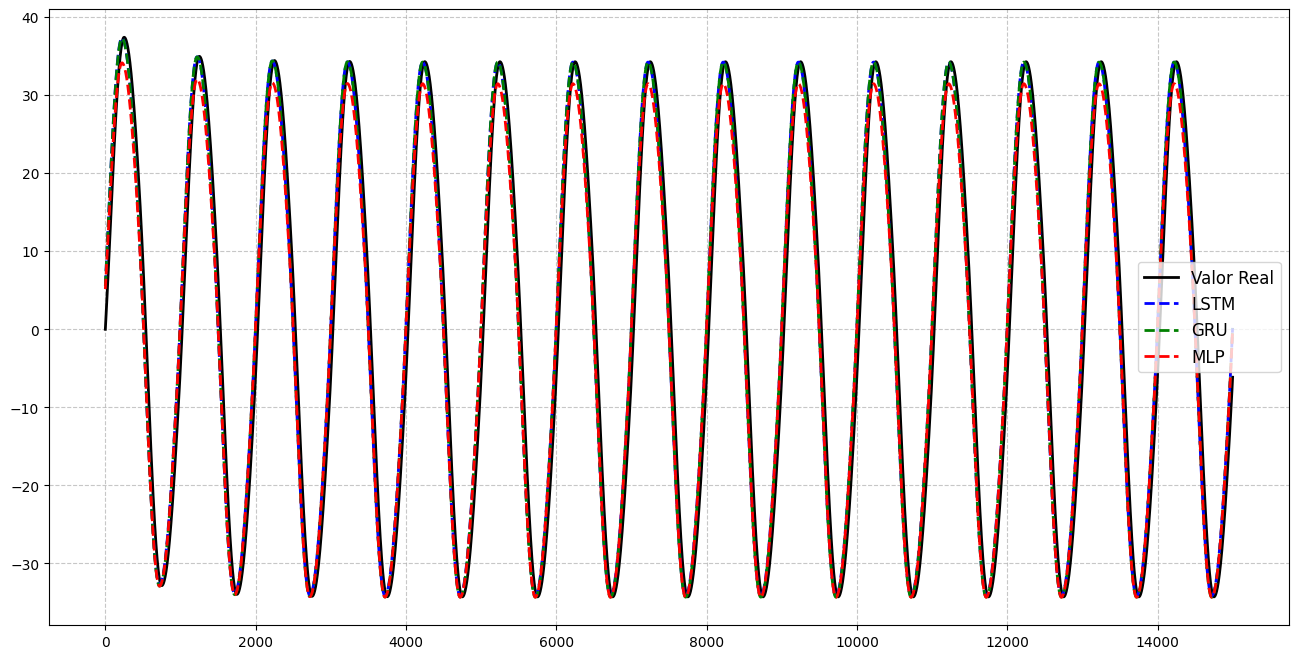

In [19]:
samples = 15000
plt.figure(figsize=(16, 8))
plt.plot(y[:samples], label=f'Valor Real', linewidth=2, color='k')
plt.plot(lstm_pred[:samples], '--', label='LSTM', linewidth=2, color='b')
plt.plot(gru_pred[:samples], '--', label='GRU', linewidth=2, color='g')
plt.plot(mlp_pred[:samples], '--', label='MLP', linewidth=2, color='r')
# plt.ylabel(" ")
# plt.xlabel(' ')
# plt.title(f' ', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
# plt.xticks(rotation=45)
# plt.savefig(f'final-results.png', dpi=300, bbox_inches='tight') 
plt.show()

In [20]:
metrics_df = pd.DataFrame({
    'Modelo': ['LSTM', 'GRU', 'MLP'],
    'MAPE (%)': [lstm_metrics[0], gru_metrics[0], mlp_metrics[0]],
    'MAE': [lstm_metrics[1], gru_metrics[1], mlp_metrics[1]],
    'R²': [lstm_metrics[2], gru_metrics[2], mlp_metrics[2]]
})

print("\nResumo das Métricas:")
print(metrics_df.to_string(index=False))


Resumo das Métricas:
Modelo  MAPE (%)      MAE       R²
  LSTM  0.715700 0.086024 0.999980
   GRU  0.930257 0.092943 0.999979
   MLP  5.197149 0.915029 0.996786
